In [1]:
import os
import torch

print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Reset working directory and pull latest code
%cd /kaggle/working

if os.path.exists('fyp-dtcr-unet'):
    !cd fyp-dtcr-unet && git fetch origin main && git reset --hard origin/main
else:
    !git clone https://github.com/shadyOg/fyp-dtcr-unet.git

%cd /kaggle/working/fyp-dtcr-unet/dtcr-unet
!pip install -q -r requirements.txt


CUDA Available: True
Device: Tesla T4
VRAM: 15.64 GB
/kaggle/working
Cloning into 'fyp-dtcr-unet'...
remote: Enumerating objects: 300, done.
remote: Counting objects: 100% (300/300), done.
remote: Compressing objects: 100% (193/193), done.
remote: Total 300 (delta 176), reused 204 (delta 86), pack-reused 0 (from 0)
Receiving objects: 100% (300/300), 2.48 MiB | 36.33 MiB/s, done.
Resolving deltas: 100% (176/176), done.
/kaggle/working/fyp-dtcr-unet/dtcr-unet


In [2]:
import os
from pathlib import Path

input_root = Path('/kaggle/input')
COVID19_PATH = None
MOSMED_PATH = None
LIDC_PATH = None

# Scan /kaggle/input and subfolders
for p in input_root.glob('*/*'):
    p_str = str(p).lower()
    
    # 1. COVID-19-CT-Seg (andrewmvd)
    if 'andrewmvd' in p_str or 'covid' in p_str:
        COVID19_PATH = str(p)
        print(f"✅ Found COVID-19-CT-Seg: {COVID19_PATH}")
        
    # 2. MosMedData (mathurinache)
    elif 'mathurinache' in p_str or 'mosmed' in p_str:
        MOSMED_PATH = str(p)
        print(f"✅ Found MosMedData: {MOSMED_PATH}")
        
    # 3. LIDC-IDRI (washingtongold)
    elif 'washingtongold' in p_str or 'lidc' in p_str:
        LIDC_PATH = str(p)
        print(f"✅ Found LIDC-IDRI: {LIDC_PATH}")

print("\n--- Summary of Detected Paths ---")
print(f"COVID19_PATH : {COVID19_PATH}")
print(f"MOSMED_PATH  : {MOSMED_PATH}")
print(f"LIDC_PATH    : {LIDC_PATH}")


✅ Found MosMedData: /kaggle/input/datasets/mathurinache
✅ Found LIDC-IDRI: /kaggle/input/datasets/washingtongold
✅ Found COVID-19-CT-Seg: /kaggle/input/datasets/andrewmvd

--- Summary of Detected Paths ---
COVID19_PATH : /kaggle/input/datasets/andrewmvd
MOSMED_PATH  : /kaggle/input/datasets/mathurinache
LIDC_PATH    : /kaggle/input/datasets/washingtongold


In [3]:
import os
import shutil
from pathlib import Path

PROCESSED_DIR = "/kaggle/working/data/processed"

if os.path.exists(PROCESSED_DIR):
    shutil.rmtree(PROCESSED_DIR)
os.makedirs(PROCESSED_DIR, exist_ok=True)

# 1. Preprocess COVID-19-CT-Seg
if COVID19_PATH:
    print("\n🚀 Preprocessing COVID-19-CT-Seg...")
    !python data/preprocessing.py \
        --covid19 "{COVID19_PATH}" \
        --out "{PROCESSED_DIR}" \
        --size 256 \
        --context 1 \
        --labeled-ratio 1.0 \
        --seed 42

# 2. Preprocess MosMedData
if MOSMED_PATH:
    print("\n🚀 Preprocessing MosMedData...")
    !python data/preprocessing.py \
        --mosmed "{MOSMED_PATH}" \
        --out "{PROCESSED_DIR}" \
        --size 256 \
        --context 1 \
        --labeled-ratio 1.0 \
        --seed 42

# 3. Preprocess LIDC-IDRI
if LIDC_PATH:
    print("\n🚀 Preprocessing LIDC-IDRI...")
    !python data/preprocessing.py \
        --lidc "{LIDC_PATH}" \
        --out "{PROCESSED_DIR}" \
        --size 256 \
        --max-patients 50 \
        --context 1 \
        --labeled-ratio 1.0 \
        --seed 42

# Summary of generated dataset
print("\n=== Combined Dataset Summary ===")
for split in ['train', 'val', 'test']:
    p = Path(PROCESSED_DIR) / split / 'images'
    n = len(list(p.glob('*.npy'))) if p.exists() else 0
    print(f"  {split.upper():<5} set: {n} slices")



🚀 Preprocessing COVID-19-CT-Seg...
Found 20 paired COVID-19-CT-Seg volumes.
Total COVID-19 cases with annotated lesions: 20
Split breakdown: Train=12 cases, Val=4 cases, Test=4 cases.
Processing COVID-19 test split: 100%|█████████████| 4/4 [00:18<00:00,  4.72s/it]

COVID-19-CT-Seg preprocessing complete!
{
  "dataset": "COVID-19-CT-Seg",
  "target_size": [
    256,
    256
  ],
  "total_extracted_slices": 3008,
  "splits": {
    "train": 1998,
    "val": 483,
    "test": 527
  },
  "semi_supervised_breakdown": {
    "train_labeled": 1998,
    "train_unlabeled": 0
  },
  "labeled_ratio": 1.0,
  "seed": 42
}

🚀 Preprocessing MosMedData...
Found 50 paired MosMed volumes.
Total annotated studies with lesions: 50
Split breakdown: Train=30 studies, Val=10 studies, Test=10 studies.
Processing test split: 100%|████████████████████| 10/10 [00:06<00:00,  1.57it/s]

Preprocessing complete!
{
  "dataset": "MosMedData",
  "target_size": [
    256,
    256
  ],
  "total_extracted_slices": 1007,
  "

In [4]:
%%bash
python train.py \
    --data /kaggle/working/data/processed \
    --epochs 80 \
    --batch-size 8 \
    --grad-accum 4 \
    --lr 0.001 \
    --labeled-ratio 1.0 \
    --lambda1 0.3 \
    --lambda2 1.0 \
    --checkpoints /kaggle/working/checkpoints \
    --outputs /kaggle/working/outputs


Using device: cuda | AMP Mixed Precision: True | Filter Empty Val Slices: True
Data ready: 3022 train samples, 728 val samples.

Starting DTCR-U-Net training for 80 epochs...

Epoch 01/80 (184.4s) | LR: 2.80e-04 | Train Loss: 1.9006 | Val Loss: 1.9187 | Val Dice: 44.62% (Lesion: 44.62%) | Val SE: 42.85% | Val SP: 99.69% | Val Acc: 96.62% | Val F1: 44.62% | Val HD: 102.61px | (Best Lesion!)
Epoch 02/80 (212.3s) | LR: 4.60e-04 | Train Loss: 1.4991 | Val Loss: 1.3294 | Val Dice: 58.22% (Lesion: 58.22%) | Val SE: 63.48% | Val SP: 99.22% | Val Acc: 99.02% | Val F1: 58.22% | Val HD: 61.08px | (Best Lesion!)
Epoch 03/80 (222.5s) | LR: 6.40e-04 | Train Loss: 1.2068 | Val Loss: 1.1296 | Val Dice: 60.24% (Lesion: 60.24%) | Val SE: 67.76% | Val SP: 98.87% | Val Acc: 98.74% | Val F1: 60.24% | Val HD: 72.45px | (Best Lesion!)
Epoch 04/80 (219.9s) | LR: 8.20e-04 | Train Loss: 0.9898 | Val Loss: 0.9870 | Val Dice: 64.64% (Lesion: 64.64%) | Val SE: 72.45% | Val SP: 99.14% | Val Acc: 99.05% | Val F1: 6

Epoch 80/80 [Train]: 100%|██████████| 377/377 [02:57<00:00,  2.12it/s, Loss=0.4545, Seg=0.3654, LSF=0.0578, DTC=0.0314]


In [5]:
%%bash
# Run test evaluation with dual-task fusion & threshold
python evaluate.py \
    --checkpoint /kaggle/working/checkpoints/best_model.pth \
    --data /kaggle/working/data/processed \
    --threshold 0.35 \
    --fuse-dual-task \
    --out /kaggle/working/outputs/evaluation \
    --batch-size 16 \
    --save-vis 10


Loading checkpoint from: /kaggle/working/checkpoints/best_model.pth
Evaluation settings: Threshold=0.35 | Dual-Task Fusion=True
Test samples: 815

      PATIENT-LEVEL 3D EVALUATION (Paper Protocol Table 2)
  DICE           : 55.98% ± 29.24%
  SENSITIVITY    : 57.09% ± 31.39%
  SPECIFICITY    : 99.90% ± 0.15%
  ACCURACY       : 99.41% ± 2.03%
  F1             : 55.98% ± 29.24%

      LESION-ONLY SLICE EVALUATION (Excl. Empty Slices)
  DICE           : 67.46 ± 37.98
  SENSITIVITY    : 68.07 ± 40.15
  SPECIFICITY    : 99.80 ± 0.25
  ACCURACY       : 97.35 ± 5.56
  F1             : 67.46 ± 37.98
  HD             : 52.69 ± 95.41

      RAW 2D SLICE EVALUATION (All Slices)
  DICE           : 67.08 ± 39.25
  SENSITIVITY    : 71.67 ± 39.14
  SPECIFICITY    : 99.82 ± 0.24
  ACCURACY       : 97.64 ± 5.30
  F1             : 67.08 ± 39.25
  HD             : 61.40 ± 109.88


Testing: 100%|██████████| 51/51 [01:00<00:00,  1.19s/it]


      PATIENT-LEVEL 3D EVALUATION SUMMARY
  DICE           : 55.98% ± 29.24%
  SENSITIVITY    : 57.09% ± 31.39%
  SPECIFICITY    : 99.90% ± 0.15%
  ACCURACY       : 99.41% ± 2.03%
  F1             : 55.98% ± 29.24%

Displaying qualitative test predictions (10 available):


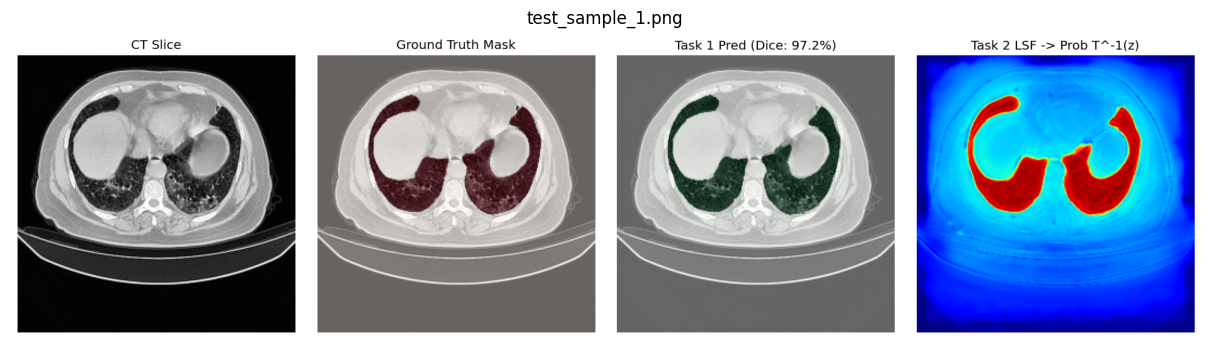

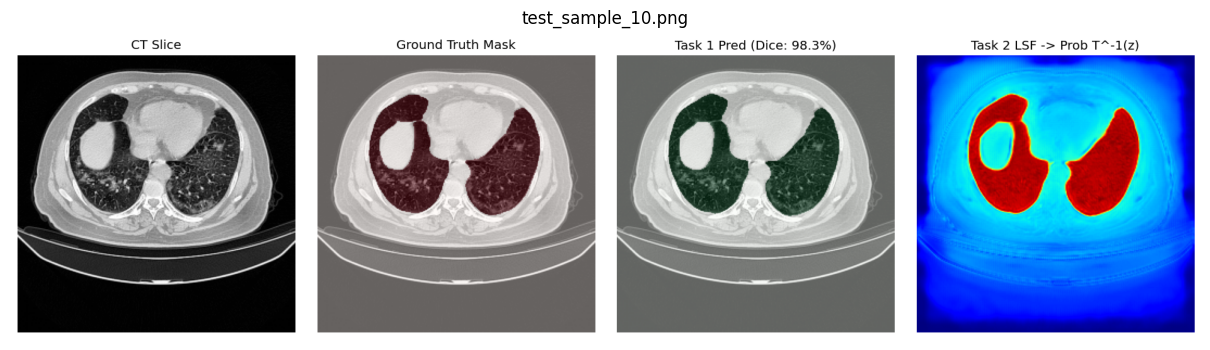

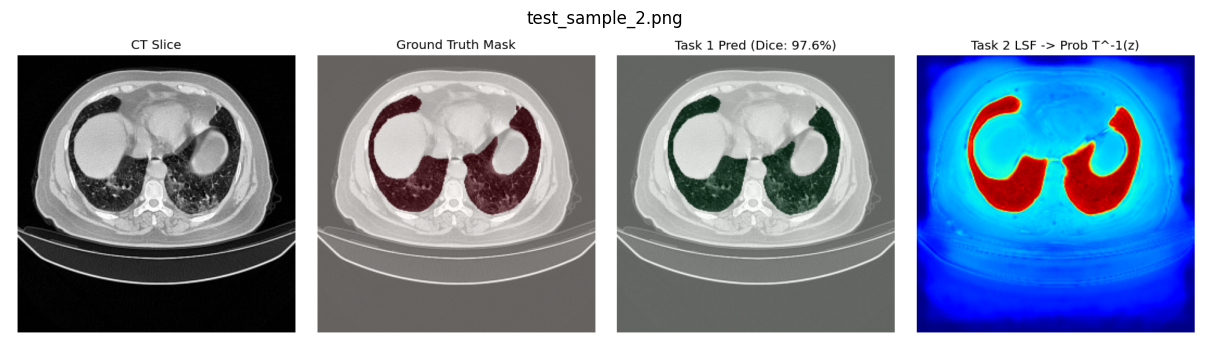

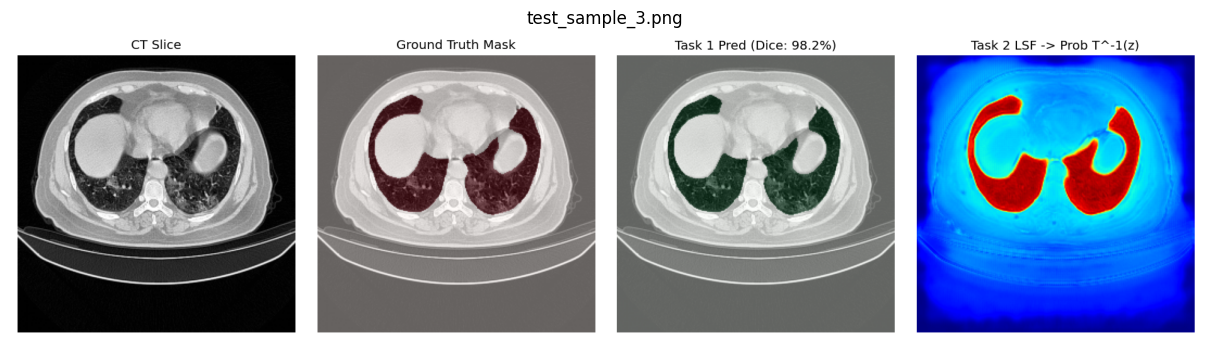

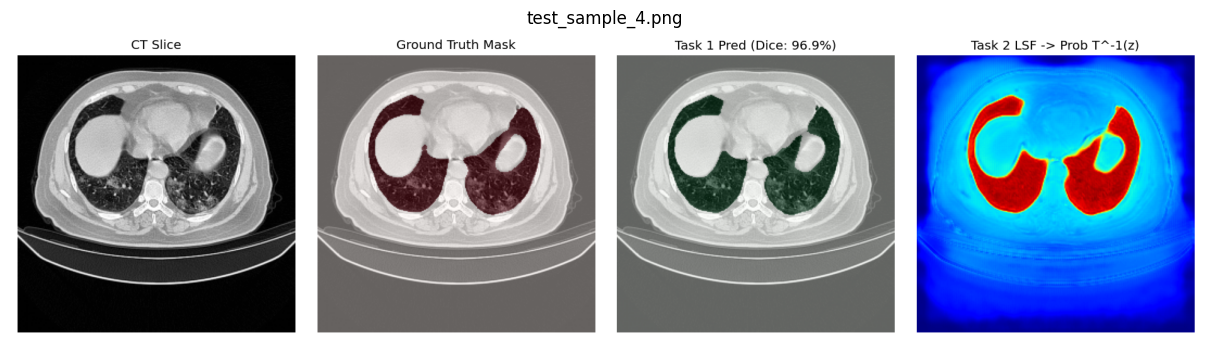

In [6]:
import json
import glob
from pathlib import Path
import matplotlib.pyplot as plt
import cv2

# 1. Print Patient-Level 3D Evaluation Metrics
metrics_file = "/kaggle/working/outputs/evaluation/test_metrics.json"
if os.path.exists(metrics_file):
    with open(metrics_file, "r") as f:
        res = json.load(f)
    print("============================================================")
    print("      PATIENT-LEVEL 3D EVALUATION SUMMARY")
    print("============================================================")
    for k, v in res.get("patient_level_3d", {}).items():
        print(f"  {k.upper():<15}: {v['mean']:.2f}% ± {v['std']:.2f}%")
    print("============================================================")

# 2. Display Sample Visual Predictions
vis_images = sorted(glob.glob("/kaggle/working/outputs/evaluation/comparisons/*.png"))
if vis_images:
    print(f"\nDisplaying qualitative test predictions ({len(vis_images)} available):")
    for img_p in vis_images[:5]:
        img = cv2.imread(img_p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(16, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(Path(img_p).name, fontsize=12)
        plt.show()
